In [3]:
%pip install astroquery scienceplots

  Using cached requests-2.32.5-py3-none-any.whl.metadata (4.9 kB)
  Using cached html5lib-1.1-py2.py3-none-any.whl.metadata (16 kB)
  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached jaraco.classes-3.4.0-py3-none-any.whl.metadata (2.6 kB)
  Using cached jaraco.context-6.0.1-py3-none-any.whl.metadata (4.1 kB)
  Using cached idna-3.11-py3-none-any.whl.metadata (8.4 kB)
  Using cached urllib3-2.6.2-py3-none-any.whl.metadata (6.6 kB)
  Using cached certifi-2025.11.12-py3-none-any.whl.metadata (2.5 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 49.8 MB/s  0:00:00m0:00:01
Using cached html5lib-1.1-py2.py3-none-any.whl (112 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 14.2 MB/s  0:00:00
Using cached requests-2.32.5-py3-none-any.whl (64 kB)
Using cached idna-3.11-py3-none-any.whl (71 kB)
Using cached urllib3-2.6.2-py3-none-any.whl (131 kB)
Using cached certifi-2025.11.12-py3-none-any.whl (159 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━

# Foreground Galaxy Identification for FRB Sample (v2.0)

This notebook identifies foreground galaxies for a sample of 12 FRBs by querying astronomical catalogs and calculating physical impact parameters. It utilizes the modular `v2.0` galaxy search toolkit.

In [6]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from astropy import units as u
from astropy.coordinates import SkyCoord
import importlib

# Add the project root to sys.path to import the v2_0 module
module_path = os.path.abspath(os.path.join('..', '..'))
if module_path not in sys.path:
    sys.path.append(module_path)

# Import v2_0 components
from galaxies.v2_0 import config, utils, engines, plotting
importlib.reload(config)
importlib.reload(utils)
importlib.reload(engines)
importlib.reload(plotting)

from galaxies.v2_0.config import TARGETS, DEFAULT_IMPACT_KPC
from galaxies.v2_0.utils import parse_coord, get_angular_radius, calculate_impact_parameter
from galaxies.v2_0.engines import NedEngine, VizierEngine
from galaxies.v2_0.plotting import use_flits_style, plot_impact_vs_redshift, plot_sightline

# Apply style
use_flits_style()

print(f"Loaded {len(TARGETS)} targets.")
print(f"First target: {TARGETS[0]}")

Loaded 12 targets.
First target: ('Zach', '20h40m47.886s', '+72d52m56.378s', 0.043)


In [ ]:
import os
print(os.getcwd())
print(os.listdir('.'))
print(os.listdir('../..'))

## 2. Loading FRB Sample Coordinates

We load the metadata for the 12 FRBs into a pandas DataFrame for easier manipulation.

In [17]:
frb_df = pd.DataFrame(TARGETS, columns=['name', 'ra_str', 'dec_str', 'z_frb'])
frb_df['target_id'] = range(1, len(frb_df) + 1)

# Parse coordinates to decimal degrees
coords = [parse_coord(r, d) for r, d in zip(frb_df.ra_str, frb_df.dec_str)]
frb_df['ra_deg'] = [c.ra.deg for c in coords]
frb_df['dec_deg'] = [c.dec.deg for c in coords]

frb_df.head()

,name,ra_str,dec_str,z_frb,target_id,ra_deg,dec_deg
0,Zach,20h40m47.886s,+72d52m56.378s,0.0430,1,310.199525,72.882327
1,Whitney,08h58m52.92s,+73d29m27.0s,0.4790,2,134.720500,73.490833
2,Oran,21h12m10.760s,+72d49m38.20s,0.3005,3,318.044833,72.827278
3,Isha,04h45m38.64s,+70d18m26.6s,0.2505,4,71.411000,70.307389
4,Wilhelm,21h00m31.09s,+72d02m15.22s,0.5100,5,315.129542,72.037561


## 3. Querying Galaxy Catalogs

We use the `NedEngine` and `VizierEngine` to search for galaxies around each FRB. For this demonstration, we'll search around the first target.

In [ ]:
# Select first target
target = frb_df.iloc[0]
coord = parse_coord(target.ra_str, target.dec_str)
radius = get_angular_radius(target.z_frb, DEFAULT_IMPACT_KPC)

print(f"Searching around Target 1 (z={target.z_frb}) with radius {radius:.2f}")

# Initialize engines
ned = NedEngine()
# Query NED
ned_results = ned.query(coord, radius)

print(f"Found {len(ned_results)} results in NED.")
ned_results.head()

## 4. Calculating Angular and Physical Separations

We calculate the physical impact parameter $b$ for each galaxy using the angular diameter distance $d_A$ at the galaxy's redshift.

In [ ]:
if not ned_results.empty:
    ned_results['impact_kpc'] = ned_results.apply(
        lambda row: calculate_impact_parameter(
            row['ra'], row['dec'], row['z'], target.ra_deg, target.dec_deg
        ), axis=1
    )
    
ned_results.head()

## 5. Identifying Foreground Galaxy Candidates

We filter for galaxies where $z_{gal} < z_{frb}$ and the impact parameter is within our threshold (e.g., 100 kpc).

In [ ]:
foreground_galaxies = ned_results[
    (ned_results['z'] < target.z_frb) & 
    (ned_results['impact_kpc'] <= DEFAULT_IMPACT_KPC)
]

print(f"Found {len(foreground_galaxies)} foreground galaxy candidates.")
foreground_galaxies.head()

## 6. Visualizing FRB-Galaxy Environments

We plot the distribution of galaxies around the FRB sightline.

Summary loaded. Targets present: ['Zach' 'Whitney' 'Oran' 'Isha' 'Wilhelm' 'Phineas' 'Freya' 'Hamilton'
 'Mahi' 'Chromatica' 'Casey' 'Johndoeii']
Loaded 3 galaxies across all targets.


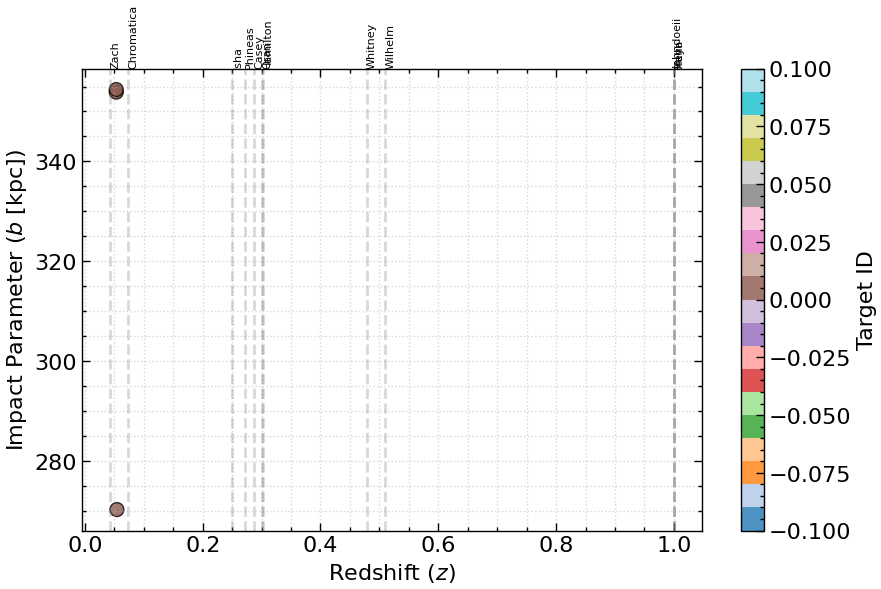

Generating sightline plot for Chromatica


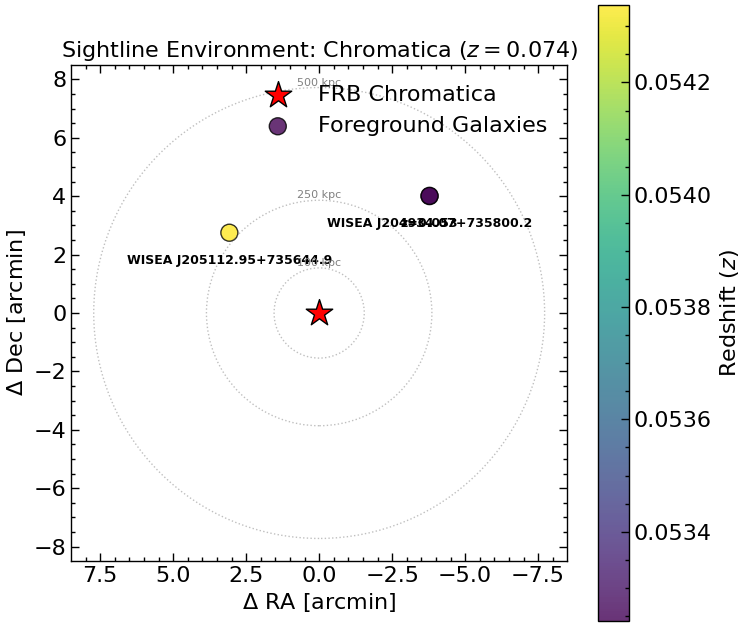

In [7]:
from galaxies.v2_0.plotting import plot_impact_vs_redshift, plot_sightline

# Use absolute paths
root_dir = '/data/jfaber/dsa110-FLITS'
results_dir = os.path.join(root_dir, 'results')

# Load summary
summary_path = os.path.join(results_dir, 'search_summary.csv')
if os.path.exists(summary_path):
    summary_df = pd.read_csv(summary_path)
    print("Summary loaded. Targets present:", summary_df['name'].unique())

    # Load all galaxies
    all_galaxies = []
    for _, row in summary_df.iterrows():
        name = row['name']
        path = os.path.join(results_dir, f'{name.lower()}_galaxies.csv')
        if os.path.exists(path):
            df = pd.read_csv(path)
            df['target_id'] = row['target_id']
            df['target_name'] = name # Use target_name to avoid collision with galaxy name
            all_galaxies.append(df)

    if all_galaxies:
        all_galaxies_df = pd.concat(all_galaxies, ignore_index=True)
        print(f"Loaded {len(all_galaxies_df)} galaxies across all targets.")
        
        # 1. Summary Plot
        fig1, ax1 = plot_impact_vs_redshift(summary_df, all_galaxies_df, output_path=os.path.join(results_dir, 'impact_vs_redshift.png'))
        plt.show()
        
        # 2. Sightline Plot for a target with results
        targets_with_results = all_galaxies_df['target_name'].unique()
        if len(targets_with_results) > 0:
            target_name = targets_with_results[0]
            print(f"Generating sightline plot for {target_name}")
            target_info = summary_df[summary_df['name'] == target_name].iloc[0].to_dict()
            target_galaxies = all_galaxies_df[all_galaxies_df['target_name'] == target_name]
            
            fig2, ax2 = plot_sightline(target_info, target_galaxies, output_path=os.path.join(results_dir, f'{target_name.lower()}_sightline.png'))
            plt.show()
    else:
        print("No foreground galaxies found to plot.")
else:
    print(f"Summary file not found at {summary_path}")

## 7. Exporting Foreground Galaxy Catalog

Finally, we save the full catalog of identified foreground galaxies across all targets to a CSV file in the results directory.

In [8]:
# Export the full catalog of identified galaxies across all targets
if 'all_galaxies_df' in locals():
    output_path = os.path.join(results_dir, 'all_foreground_galaxies.csv')
    all_galaxies_df.to_csv(output_path, index=False)
    print(f"Saved {len(all_galaxies_df)} galaxies to {output_path}")
elif 'foreground_galaxies' in locals():
    foreground_galaxies.to_csv('foreground_galaxies_v2.csv', index=False)
    print(f"Saved {len(foreground_galaxies)} galaxies to foreground_galaxies_v2.csv")
else:
    print("No galaxy data found to export. Please ensure the search and data loading cells have been executed.")

Saved 3 galaxies to /data/jfaber/dsa110-FLITS/results/all_foreground_galaxies.csv
